Random_state:  4
Tree>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
Y_pred
[[ True False]
 [False  True]
 [ True False]
 [ True  True]
 [ True False]
 [False  True]
 [ True False]
 [False  True]
 [False  True]]
Y_test
[[1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]]
---------------------------------------------------------------------


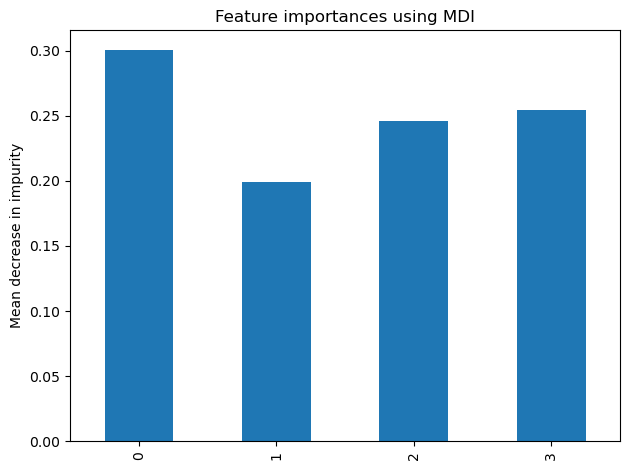

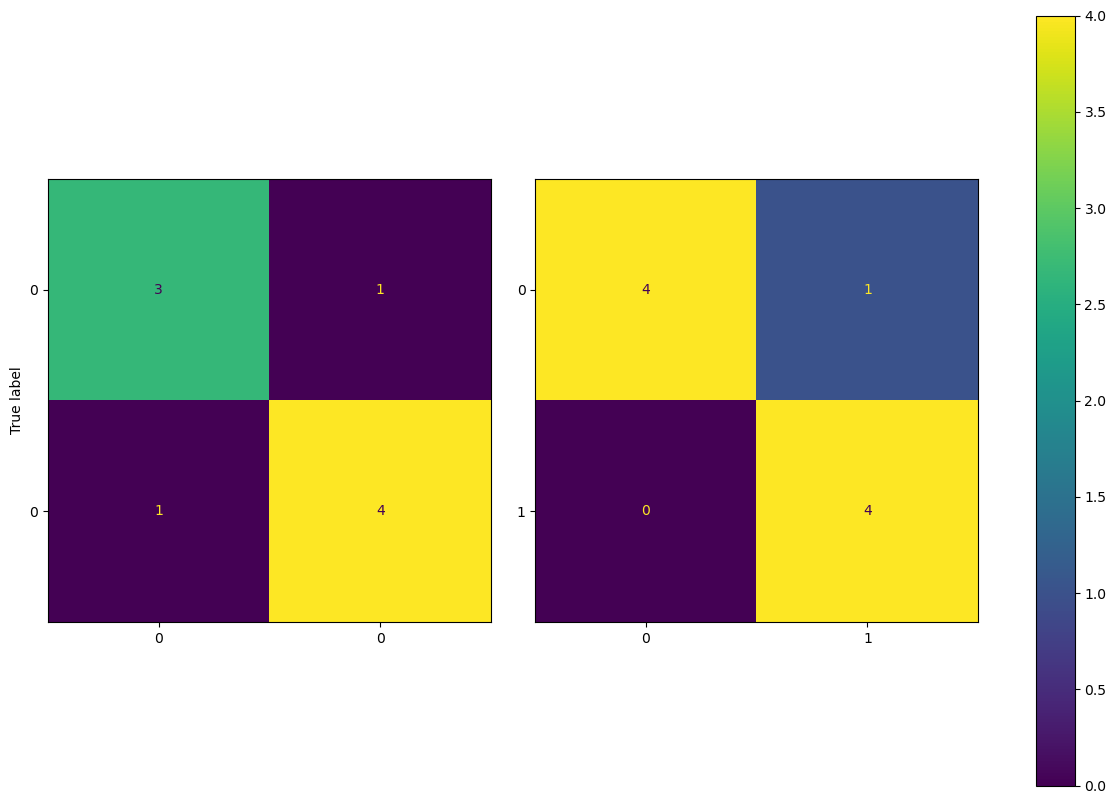

Accuracy: 77.77777777777779 %
              precision    recall  f1-score   support

     healing       0.80      0.80      0.80         5
 Not-healing       0.80      1.00      0.89         4

   micro avg       0.80      0.89      0.84         9
   macro avg       0.80      0.90      0.84         9
weighted avg       0.80      0.89      0.84         9
 samples avg       0.83      0.89      0.85         9



<Figure size 40000x12000 with 0 Axes>

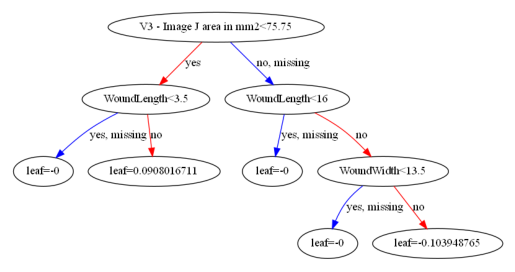

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import re
import matplotlib
import numpy as np
import pandas as pd
import xgboost as xgb
from xgboost import plot_tree
import graphviz
from xgboost import XGBRegressor
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import random
from tensorflow.keras.utils import to_categorical

Treatment=pd.read_csv("../dissertation/knitted dresing-prepared_V5.csv")


df_x=Treatment.iloc[:,1:]
df_y=Treatment.iloc[:,0]
R_state=random.randrange(1,100)
print("Random_state: ",R_state)
R_state=23


X_train, X_test, y_train, y_test = train_test_split(df_x, df_y, test_size=0.15, random_state=R_state,stratify=df_y)
#X_train, X_test, y_train, y_test = train_test_split(df_x, df_y, test_size=0.13,stratify=df_y)


y_train = to_categorical(y_train)
y_test = to_categorical(y_test)


print("Tree>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>")


clfs=XGBClassifier(tree_method="hist",
                colsample_bynode=0.3,
                    colsample_bylevel=0.2,
                  colsample_bytree=0.8,
                    subsample=0.6,
                    min_child_weight=0.2,
                    objective="reg:pseudohubererror",
                    max_bin=2056,
                     eta=0.2,
                  reg_alpha=0.1,
                  num_parallel_tree=15,
                  reg_lambda=0.07,
                  n_estimators=670,
                  max_depth=None
)

clf=XGBClassifier(tree_method="exact",
                  #objective="reg:pseudohubererror",
                  objective="binary:logitraw",
                  max_depth=10,
                   subsample=0.7,
                  reg_alpha=0.5,
                 reg_lambda=0.4,
                  eta=0.2,
                  max_bin=2056,
                  min_child_weight=0.3,
                  colsample_bylevel=0.7,
                  colsample_bynode=0.7,
                  colsample_bytree=0.7,
                 num_parallel_tree=20,
                  n_estimators=670,
                  grow_policy="lossguide",
)

clf=XGBClassifier(tree_method="exact",
                  eta=0.2,
                  subsample=0.5,
                 
                   objective="reg:pseudohubererror",
                   max_bin=2056,
                    reg_alpha=0.5,
                 reg_lambda=0.4,
                   )




clf.fit(X_train, y_train)




    
def accuracy_report():
    y_pred = clf.predict(X_test)
    y_pred = (y_pred > 0.5) 
    print("Y_pred")
    print(y_pred)
    print("Y_test")
    print(y_test)

    accuracy = accuracy_score(y_test, y_pred)
    importances = clf.feature_importances_
    forest_importances = pd.Series(importances)
    fig, ax = plt.subplots()
    forest_importances.plot.bar( ax=ax)
    ax.set_title("Feature importances using MDI")
    ax.set_ylabel("Mean decrease in impurity")
    fig.tight_layout()
    print("---------------------------------------------------------------------")
    

    f, axes = plt.subplots(1, 2, figsize=(15, 10))
    axes = axes.ravel()
    #goal_class=["Healing","non-healing","deterioration"]
    for i in range(2):
        disp = ConfusionMatrixDisplay(confusion_matrix(y_test[:, i],
                                                       y_pred[:, i]),
                                      display_labels=[0, i])
        disp.plot(ax=axes[i], values_format='.4g')
        #disp.ax_.set_title(goal_class[i])
        if i<10:
            disp.ax_.set_xlabel('')
        if i%5!=0:
            disp.ax_.set_ylabel('')
        disp.im_.colorbar.remove()

    plt.subplots_adjust(wspace=0.10, hspace=0.1)
    f.colorbar(disp.im_, ax=axes)
    plt.show()
    print("Accuracy:", (accuracy*100),"%")
    
    
    
    print(classification_report(y_test,y_pred,output_dict=False,target_names=["healing","Not-healing"]))
    
def plot_xgb_tree():
    plt.figure(figsize=(400, 120))
    plot_tree(clf)
    plt.savefig('DTC keras', dpi=1200)
    
    
    f = open("out.txt", "w")
    var=clf.get_booster().get_dump()
    for line in var:
        f.write(f"{line}\n")
    f.close()

    

accuracy_report()
plot_xgb_tree()

